In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('student_lifestyle_performance_dataset.csv')
df

,Age,Branch,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Diet_Type,Attendance_Percentage,Stress_Level_1_to_10,Residence,Internal_Marks,CGPA
0,23,ECE,4.14,6.84,9.23,2.67,Non-Veg,81.24,4.93,Hosteller,65.86,7.52
1,20,Civil,5.97,5.52,3.09,15.61,Veg,90.55,6.96,Day Scholar,62.52,7.21
2,24,Electrical,3.19,3.39,5.02,2.52,Veg,69.40,7.38,Hosteller,40.11,4.84
3,21,CSE,4.77,6.44,9.21,0.00,Non-Veg,80.79,5.84,Day Scholar,61.25,6.74
4,23,Civil,5.42,6.54,4.76,9.93,Veg,82.63,6.67,Day Scholar,64.54,7.77
...,...,...,...,...,...,...,...,...,...,...,...,...
995,24,IT,4.60,5.26,4.23,12.64,Non-Veg,82.95,7.12,Day Scholar,69.63,6.65
996,17,IT,4.02,6.55,3.88,2.86,Non-Veg,89.29,4.19,Hosteller,66.97,7.77
997,25,CSE,4.28,8.43,4.64,0.00,Veg,74.57,2.80,Day Scholar,80.52,8.04
998,23,Civil,6.42,6.06,4.84,10.08,Non-Veg,91.57,6.76,Day Scholar,77.48,7.24


In [3]:
df.isnull().sum()
#No null values.

Age                      0
Branch                   0
Study_Hours_per_Day      0
Sleep_Hours              0
Screen_Time_Hours        0
Gym_Hours_per_Week       0
Diet_Type                0
Attendance_Percentage    0
Stress_Level_1_to_10     0
Residence                0
Internal_Marks           0
CGPA                     0
dtype: int64

In [4]:
x = df.drop('CGPA', axis=1)
y = df['CGPA']  

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [6]:
categorical_cols = x.select_dtypes(include=['object']).columns.tolist()

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),   # same as before
    ('model', LinearRegression())
])

In [27]:
linear_pipeline.fit(X_train, y_train)
y_pred_ln = linear_pipeline.predict(X_test)

In [28]:
from sklearn.metrics import r2_score, root_mean_squared_error

print("R2:", r2_score(y_test, y_pred_ln))
print("RMSE:", root_mean_squared_error(y_test, y_pred_ln))

R2: 0.8799002274664041
RMSE: 0.348642669831742


In [25]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    linear_pipeline,   # ⚠️ use pipeline, not model
    x,
    y,
    cv=3,
    scoring='r2'
)

print("Cross Validation R2 Scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

Cross Validation R2 Scores: [0.86377674 0.85712622 0.80291724]
Mean CV R2: 0.841273400114448


In [19]:
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', Ridge(alpha=1.0))
])

In [29]:
ridge_pipeline.fit(X_train, y_train)
y_pred_rg = linear_pipeline.predict(X_test)

In [30]:
from sklearn.metrics import r2_score, root_mean_squared_error

print("R2:", r2_score(y_test, y_pred_rg))
print("RMSE:", root_mean_squared_error(y_test, y_pred_rg))

R2: 0.8799002274664041
RMSE: 0.348642669831742


In [24]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    ridge_pipeline,
    x,
    y,
    cv=3,
    scoring='r2'
)

print("Cross Validation R2 Scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

Cross Validation R2 Scores: [0.86384324 0.8571548  0.80288479]
Mean CV R2: 0.8412942771169806


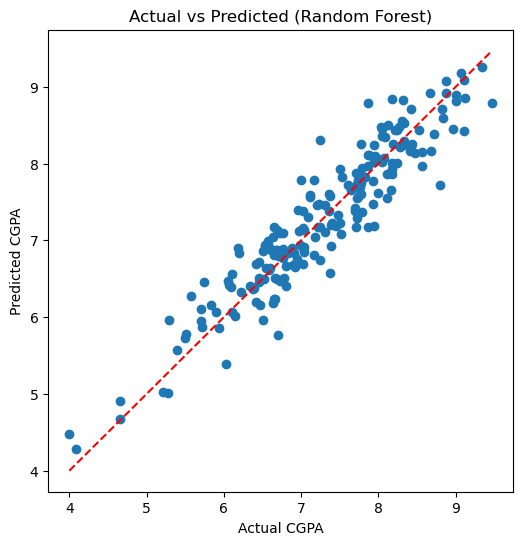

In [ ]:
#Actual vs Predicted Scatter Plot 
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rg)
plt.xlabel("Actual CGPA")
plt.ylabel("Predicted CGPA")
plt.title("Actual vs Predicted (Random Forest)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

The plot shows a strong alignment of points along the diagonal line, indicating that the model’s predictions closely match the actual CGPA values. This suggests high accuracy and good model performance, with only minor deviations showing small prediction errors.

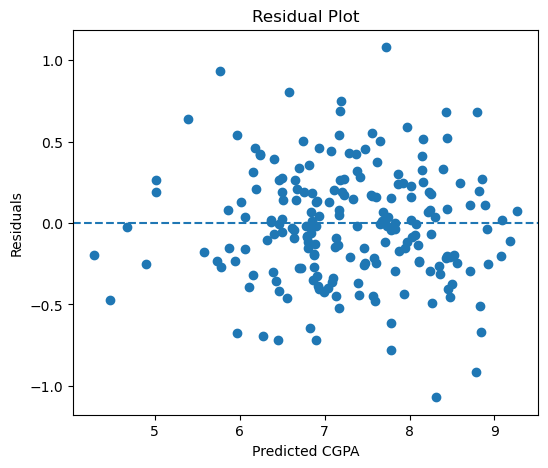

In [ ]:
#Residual Plot (Error Analysis)
residuals = y_test - y_pred_rg

plt.figure(figsize=(6,5))
plt.scatter(y_pred_rg, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted CGPA")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

The residual plot shows that the errors are randomly scattered around zero, indicating that the model is unbiased and captures the overall relationship well. There is no clear pattern or curvature, suggesting a good model fit, though a slight increase in error spread at higher CGPA values and a few outliers indicate minor variability that could be improved.

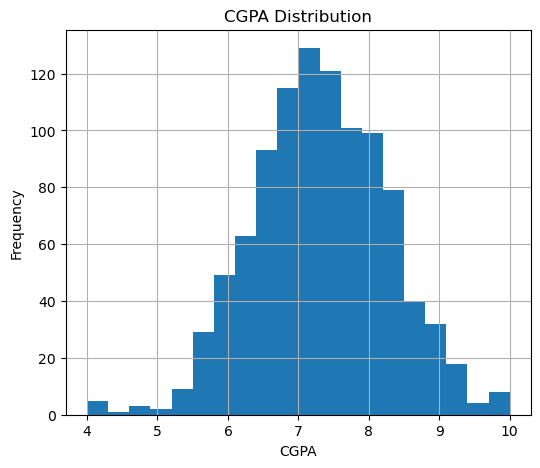

In [ ]:
#CGPA Distribution
plt.figure(figsize=(6,5))
df['CGPA'].hist(bins=20)
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.title("CGPA Distribution")
plt.show()

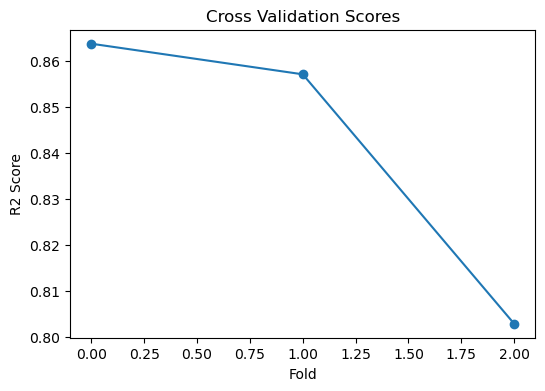

In [35]:
plt.figure(figsize=(6,4))
plt.plot(cv_scores, marker='o')
plt.xlabel("Fold")
plt.ylabel("R2 Score")
plt.title("Cross Validation Scores")
plt.show()

The cross-validation plot shows consistently high R² scores across folds, indicating that the model performs reliably on different subsets of the data. Although there is a slight drop in one fold, the overall variation is low, suggesting good generalization and stability of the model.

END OF DOCUMENT